In [ ]:
# Cell 1: Install all dependencies
!pip install speechbrain librosa opacus soundfile pesq pystoi -q
!pip install torch torchaudio --upgrade -q

In [6]:
# Cell 2: Imports and verify setup
import torch
import torchaudio
import librosa
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio, display

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Torch version: {torch.__version__}")
print(f"Torchaudio version: {torchaudio.__version__}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found")

Device: cuda
Torch version: 2.11.0+cu130
Torchaudio version: 2.11.0+cu130
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
# Cell 3: Download VCTK via torchaudio
import os

os.makedirs("/content/vctk", exist_ok=True)

print("Downloading VCTK...")
dataset = torchaudio.datasets.VCTK_092(
    root="/content/vctk",
    download=True
)

print(f"Total samples: {len(dataset)}")

# Peek at one sample
waveform, sample_rate, transcript, speaker_id, utterance_id = dataset[0]
print(f"Sample rate: {sample_rate}")
print(f"Waveform shape: {waveform.shape}")
print(f"Speaker ID: {speaker_id}")
print(f"Transcript: {transcript}")

In [ ]:
# Cell 4: Fix audio loading - install ffmpeg and use librosa/soundfile directly
!apt-get install -y ffmpeg -q

import os
import glob
import librosa
import numpy as np
import soundfile as sf
from collections import defaultdict

# The VCTK files are already downloaded, find them
vctk_audio_path = "/content/vctk/VCTK-Corpus-0.92/wav48_silence_trimmed"
speakers = sorted(os.listdir(vctk_audio_path))
print(f"Total speakers available: {len(speakers)}")
print(f"First 10 speakers: {speakers[:10]}")

# Pick just 4 speakers
selected_speakers = speakers[:4]
print(f"\nSelected speakers: {selected_speakers}")

# Collect up to 20 utterances per speaker
speaker_files = defaultdict(list)
for spk in selected_speakers:
    flac_files = glob.glob(f"{vctk_audio_path}/{spk}/*.flac")[:20]
    speaker_files[spk] = flac_files
    print(f"  {spk}: {len(flac_files)} files")

# Test loading one file
sample_path = speaker_files[selected_speakers[0]][0]
wav, sr = librosa.load(sample_path, sr=16000)
print(f"\n Audio loaded OK")
print(f"   Sample rate: {sr}")
print(f"   Duration: {len(wav)/sr:.2f}s")
print(f"   Shape: {wav.shape}")

In [9]:
# Cell 5: Fix speaker selection - filter out non-speaker entries
vctk_audio_path = "/content/vctk/VCTK-Corpus-0.92/wav48_silence_trimmed"

# Filter only valid speaker folders (start with 'p')
all_speakers = sorted(os.listdir(vctk_audio_path))
speakers = [s for s in all_speakers if s.startswith('p')]
print(f"Valid speakers: {len(speakers)}")

# Pick 4 speakers
selected_speakers = speakers[:4]
print(f"Selected: {selected_speakers}")

# Collect up to 20 utterances per speaker
speaker_files = defaultdict(list)
for spk in selected_speakers:
    flac_files = sorted(glob.glob(f"{vctk_audio_path}/{spk}/*.flac"))[:20]
    speaker_files[spk] = flac_files
    print(f"  {spk}: {len(flac_files)} files")

# Test loading one file
sample_path = speaker_files[selected_speakers[0]][0]
wav, sr = librosa.load(sample_path, sr=16000)
print(f"\n Audio loaded OK")
print(f"   Sample rate: {sr}")
print(f"   Duration: {len(wav)/sr:.2f}s")
print(f"   Shape: {wav.shape}")

# Play it
from IPython.display import Audio, display
display(Audio(wav, rate=sr))

Valid speakers: 109
Selected: ['p225', 'p226', 'p227', 'p228']
  p225: 20 files
  p226: 20 files
  p227: 20 files
  p228: 20 files

 Audio loaded OK
   Sample rate: 16000
   Duration: 2.05s
   Shape: (32825,)


Extracting Mel-spectrograms...
   Mels shape: (80, 80, 128)
   Labels shape: (80,)
   Speaker map: {'p225': 0, 'p226': 1, 'p227': 2, 'p228': 3}


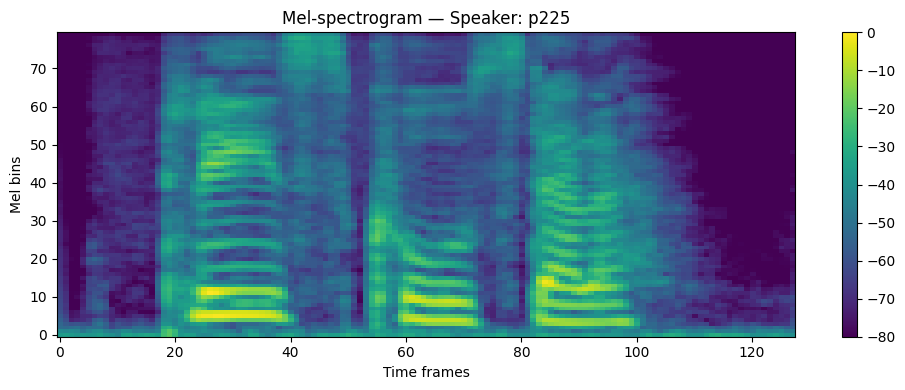

In [10]:
# Cell 6: Extract Mel-spectrograms for all speakers
import torch

# Mel-spectrogram parameters
SR = 16000
N_FFT = 1024
HOP_LENGTH = 256
N_MELS = 80
MAX_FRAMES = 128  # ~2 seconds, we'll pad/trim all to same length

def wav_to_mel(path, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
               n_mels=N_MELS, max_frames=MAX_FRAMES):
    wav, _ = librosa.load(path, sr=sr)
    mel = librosa.feature.melspectrogram(
        y=wav, sr=sr, n_fft=n_fft,
        hop_length=hop_length, n_mels=n_mels
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)  # shape: (80, T)

    # Pad or trim to fixed length
    if mel_db.shape[1] < max_frames:
        mel_db = np.pad(mel_db, ((0,0), (0, max_frames - mel_db.shape[1])))
    else:
        mel_db = mel_db[:, :max_frames]

    return mel_db  # shape: (80, 128)

# Extract all mels and build dataset
print("Extracting Mel-spectrograms...")
all_mels = []
all_labels = []
speaker_to_idx = {spk: i for i, spk in enumerate(selected_speakers)}

for spk in selected_speakers:
    for path in speaker_files[spk]:
        mel = wav_to_mel(path)
        all_mels.append(mel)
        all_labels.append(speaker_to_idx[spk])

all_mels = np.array(all_mels)    # (80, 80, 128)
all_labels = np.array(all_labels)

print(f"   Mels shape: {all_mels.shape}")  # (80, 80, 128)
print(f"   Labels shape: {all_labels.shape}")
print(f"   Speaker map: {speaker_to_idx}")

# Visualize one mel
plt.figure(figsize=(10, 4))
plt.imshow(all_mels[0], aspect='auto', origin='lower')
plt.colorbar()
plt.title(f"Mel-spectrogram — Speaker: {selected_speakers[0]}")
plt.xlabel("Time frames")
plt.ylabel("Mel bins")
plt.tight_layout()
plt.show()

In [11]:
# Cell 7: VAE Voice Conversion Model
import torch
import torch.nn as nn
import torch.nn.functional as F

# Content Encoder
class ContentEncoder(nn.Module):
    """Encodes WHAT is being said (strips speaker identity)"""
    def __init__(self, n_mels=80, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_mels, 256, kernel_size=5, padding=2), nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=5, padding=2),    nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=5, padding=2),    nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

    def forward(self, mel):
        # mel: (B, 80, T)
        h = self.net(mel)           # (B, 256, T)
        h = h.mean(dim=2)           # (B, 256) — pool over time
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

# Speaker Encoder
class SpeakerEncoder(nn.Module):
    """Encodes WHO is speaking"""
    def __init__(self, n_mels=80, spk_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_mels, 128, kernel_size=5, padding=2), nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=5, padding=2),    nn.ReLU(),
        )
        self.fc = nn.Linear(128, spk_dim)

    def forward(self, mel):
        h = self.net(mel).mean(dim=2)   # (B, 128)
        return self.fc(h)               # (B, spk_dim)

# Decoder
class Decoder(nn.Module):
    """Reconstructs mel from content latent + speaker embedding"""
    def __init__(self, latent_dim=128, spk_dim=64, n_mels=80, n_frames=128):
        super().__init__()
        self.n_frames = n_frames
        self.fc = nn.Linear(latent_dim + spk_dim, 256 * 4)
        self.net = nn.Sequential(
            nn.ConvTranspose1d(256, 256, kernel_size=5, padding=2), nn.ReLU(),
            nn.ConvTranspose1d(256, 256, kernel_size=5, padding=2), nn.ReLU(),
            nn.ConvTranspose1d(256, n_mels, kernel_size=5, padding=2),
        )

    def forward(self, content, speaker):
        # content: (B, latent_dim), speaker: (B, spk_dim)
        x = torch.cat([content, speaker], dim=1)   # (B, latent+spk)
        x = self.fc(x)                              # (B, 256*4)
        x = x.view(x.size(0), 256, 4)              # (B, 256, 4)
        x = F.interpolate(x, size=self.n_frames)   # (B, 256, 128)
        return self.net(x)                          # (B, 80, 128)

# Full VAE Voice Conversion Model
class VAEVoiceConverter(nn.Module):
    def __init__(self, n_mels=80, latent_dim=128, spk_dim=64, n_frames=128):
        super().__init__()
        self.content_encoder = ContentEncoder(n_mels, latent_dim)
        self.speaker_encoder = SpeakerEncoder(n_mels, spk_dim)
        self.decoder         = Decoder(latent_dim, spk_dim, n_mels, n_frames)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, src_mel, tgt_mel):
        # Encode content from source
        mu, logvar = self.content_encoder(src_mel)
        content    = self.reparameterize(mu, logvar)
        # Encode speaker from target
        speaker    = self.speaker_encoder(tgt_mel)
        # Decode: source content + target speaker
        recon      = self.decoder(content, speaker)
        return recon, mu, logvar

    def convert(self, src_mel, tgt_mel):
        """Inference only — no sampling noise"""
        with torch.no_grad():
            mu, _   = self.content_encoder(src_mel)
            speaker = self.speaker_encoder(tgt_mel)
            return self.decoder(mu, speaker)

# Sanity check
model = VAEVoiceConverter().to(device)
dummy_src = torch.randn(4, 80, 128).to(device)
dummy_tgt = torch.randn(4, 80, 128).to(device)
recon, mu, logvar = model(dummy_src, dummy_tgt)

print("  Model built successfully")
print(f"   Input shape:  {dummy_src.shape}")
print(f"   Output shape: {recon.shape}")
print(f"   Mu shape:     {mu.shape}")
total_params = sum(p.numel() for p in model.parameters())
print(f"   Total params: {total_params:,}")

  Model built successfully
   Input shape:  torch.Size([4, 80, 128])
   Output shape: torch.Size([4, 80, 128])
   Mu shape:     torch.Size([4, 128])
   Total params: 1,921,936


In [ ]:
# Cell 8: Differential Privacy via Opacus
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
from torch.utils.data import DataLoader, TensorDataset

# Validate & fix model for Opacus
# Opacus requires no BatchNorm layers
errors = ModuleValidator.validate(model, strict=False)
if errors:
    print(f"Fixing {len(errors)} compatibility issues...")
    model = ModuleValidator.fix(model)
else:
    print("  Model is Opacus-compatible, no fixes needed")

# Prepare DataLoader
mels_tensor   = torch.FloatTensor(all_mels)    # (80, 80, 128)
labels_tensor = torch.LongTensor(all_labels)   # (80,)

# Normalize mels to [-1, 1]
mel_min = mels_tensor.min()
mel_max = mels_tensor.max()
mels_norm = 2 * (mels_tensor - mel_min) / (mel_max - mel_min) - 1

dataset_tensor = TensorDataset(mels_norm, labels_tensor)
train_loader   = DataLoader(dataset_tensor, batch_size=16, shuffle=True)

print(f"  DataLoader ready")
print(f"   Batches per epoch: {len(train_loader)}")
print(f"   Mel range after norm: [{mels_norm.min():.2f}, {mels_norm.max():.2f}]")

# Optimizer + Privacy Engine
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

privacy_engine = PrivacyEngine()

model_dp, optimizer_dp, train_loader_dp = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=1.0,   # controls privacy noise strength
    max_grad_norm=1.0,      # gradient clipping bound (sensitivity)
)

print(f"\n Differential Privacy engine attached")
print(f"   Noise multiplier (σ): 1.0")
print(f"   Max grad norm (C):    1.0")
print(f"   Mechanism: Gaussian noise on per-sample gradients")

 Fresh DP engine attached
Training VAE with Differential Privacy...
 Epoch   Total Loss   Recon Loss    KL Loss          ε
--------------------------------------------------------
     1       0.4706       0.4705     0.0016     3.8908
    10       0.3561       0.3561     0.0019    10.1386
    20       0.2217       0.2216     0.0026    14.5383
    30       0.1953       0.1953     0.0032    18.2293
    40       0.1912       0.1911     0.0044    21.5520
    50       0.1919       0.1918     0.0067    24.6385

 Training complete in 32.7s
   Final ε = 24.6385  (lower = more private)


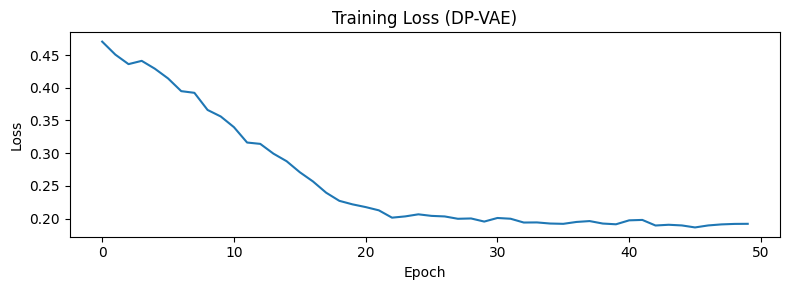

In [15]:
# Cell 9 (fixed): Training loop with DP
import time

# Rebuild model fresh to clear double-hook issue
model = VAEVoiceConverter().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
privacy_engine = PrivacyEngine()

model_dp, optimizer_dp, train_loader_dp = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=1.0,
    max_grad_norm=1.0,
)
print(" Fresh DP engine attached")

def vae_loss(recon, target, mu, logvar, kl_weight=0.01):
    recon_loss = F.mse_loss(recon, target)
    kl_loss    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_weight * kl_loss, recon_loss, kl_loss

EPOCHS = 50
losses = []

print("Training VAE with Differential Privacy...")
print(f"{'Epoch':>6} {'Total Loss':>12} {'Recon Loss':>12} {'KL Loss':>10} {'ε':>10}")
print("-" * 56)

model_dp.train()
start = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_loss = epoch_recon = epoch_kl = 0

    for mels, labels in train_loader_dp:
        mels    = mels.to(device)
        src_mel = mels
        tgt_mel = mels[torch.randperm(mels.size(0))]

        optimizer_dp.zero_grad()
        recon, mu, logvar = model_dp(src_mel, tgt_mel)
        loss, recon_loss, kl_loss = vae_loss(recon, src_mel, mu, logvar)
        loss.backward()
        optimizer_dp.step()

        epoch_loss  += loss.item()
        epoch_recon += recon_loss.item()
        epoch_kl    += kl_loss.item()

    avg_loss  = epoch_loss  / len(train_loader_dp)
    avg_recon = epoch_recon / len(train_loader_dp)
    avg_kl    = epoch_kl    / len(train_loader_dp)
    losses.append(avg_loss)

    # Epsilon only reliable after a few epochs
    try:
        epsilon = privacy_engine.get_epsilon(delta=1e-5)
        eps_str = f"{epsilon:.4f}"
    except:
        eps_str = "computing..."

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>6} {avg_loss:>12.4f} {avg_recon:>12.4f} {avg_kl:>10.4f} {eps_str:>10}")

elapsed = time.time() - start
try:
    final_eps = privacy_engine.get_epsilon(delta=1e-5)
    print(f"\n Training complete in {elapsed:.1f}s")
    print(f"   Final ε = {final_eps:.4f}  (lower = more private)")
except:
    print(f"\n Training complete in {elapsed:.1f}s")
    print(f"   ε could not be computed (too few steps for PRV accountant)")

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title("Training Loss (DP-VAE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

  Voice conversion complete
   Source speaker:    p225
   Target speaker:    p227

  Original source (p225):



 Target reference (p227):



 Converted (src content + tgt speaker):


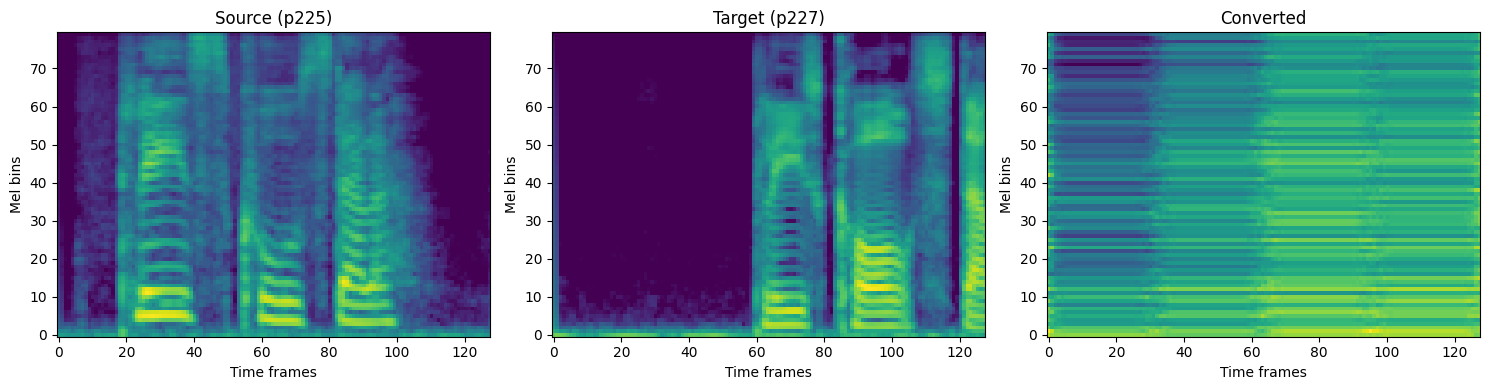

In [17]:
# Cell 10: Voice Conversion Inference
model_dp.eval()

def denormalize_mel(mel_norm, mel_min, mel_max):
    return (mel_norm + 1) / 2 * (mel_max - mel_min) + mel_min

def mel_to_audio(mel_db, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """Convert mel-spectrogram back to audio using Griffin-Lim"""
    mel_power = librosa.db_to_power(mel_db)
    wav = librosa.feature.inverse.mel_to_audio(
        mel_power, sr=sr, n_fft=n_fft, hop_length=hop_length, n_iter=60
    )
    return wav

# Pick source = p225 (speaker 0), target = p227 (speaker 2)
src_spk = 'p225'
tgt_spk = 'p227'

src_idx = speaker_to_idx[src_spk]
tgt_idx = speaker_to_idx[tgt_spk]

# Grab one utterance from each
src_mel_np = all_mels[src_idx * 20 + 0]   # first utterance of p225
tgt_mel_np = all_mels[tgt_idx * 20 + 0]   # first utterance of p227

# Normalize same way as training
src_mel_norm = 2 * (torch.FloatTensor(src_mel_np) - mel_min) / (mel_max - mel_min) - 1
tgt_mel_norm = 2 * (torch.FloatTensor(tgt_mel_np) - mel_min) / (mel_max - mel_min) - 1

src_tensor = src_mel_norm.unsqueeze(0).to(device)  # (1, 80, 128)
tgt_tensor = tgt_mel_norm.unsqueeze(0).to(device)  # (1, 80, 128)

# Convert: source content + target speaker
converted_norm = model_dp._module.convert(src_tensor, tgt_tensor)
converted_norm = converted_norm.squeeze(0).cpu().numpy()  # (80, 128)

# Denormalize
converted_mel = denormalize_mel(converted_norm, mel_min.numpy(), mel_max.numpy())

# Convert all three to audio
src_audio     = mel_to_audio(src_mel_np)
tgt_audio     = mel_to_audio(tgt_mel_np)
converted_audio = mel_to_audio(converted_mel)

print(f"  Voice conversion complete")
print(f"   Source speaker:    {src_spk}")
print(f"   Target speaker:    {tgt_spk}")
print(f"\n  Original source ({src_spk}):")
display(Audio(src_audio, rate=SR))

print(f"\n Target reference ({tgt_spk}):")
display(Audio(tgt_audio, rate=SR))

print(f"\n Converted (src content + tgt speaker):")
display(Audio(converted_audio, rate=SR))

# Plot spectrograms side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, mel, title in zip(axes,
    [src_mel_np, tgt_mel_np, converted_mel],
    [f"Source ({src_spk})", f"Target ({tgt_spk})", "Converted"]):
    ax.imshow(mel, aspect='auto', origin='lower')
    ax.set_title(title)
    ax.set_xlabel("Time frames")
    ax.set_ylabel("Mel bins")
plt.tight_layout()
plt.show()

Computing speaker embeddings...
  p225: embedding shape (1, 64)
  p226: embedding shape (1, 64)
  p227: embedding shape (1, 64)
  p228: embedding shape (1, 64)

── Without Conversion (baseline) ──
  Speaker ID accuracy (original): 80.00%

── After Voice Conversion (privacy test) ──
  Speaker ID accuracy (converted): 25.00%

── Privacy Summary ──
  Baseline accuracy:  80.00%
  Post-conversion:    25.00%
  Identity leakage ↓: 55.00% reduction
  DP Privacy budget:  ε = 24.64, δ = 1e-5


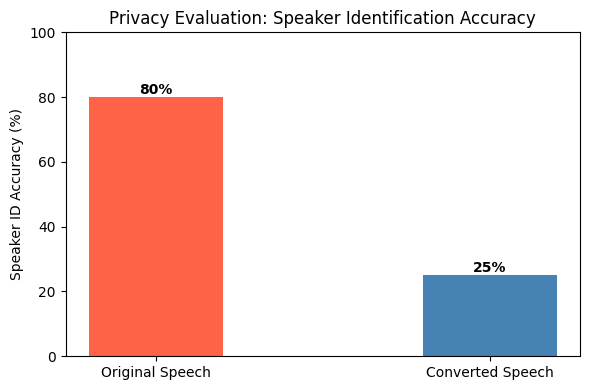

In [19]:
# Cell 11: Evaluation
from sklearn.metrics.pairwise import cosine_similarity
from torch.nn.functional import normalize

model_dp.eval()

def get_speaker_embedding(mel_np):
    """Extract speaker embedding from a mel spectrogram"""
    mel_norm = 2 * (torch.FloatTensor(mel_np) - mel_min) / (mel_max - mel_min) - 1
    mel_tensor = mel_norm.unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model_dp._module.speaker_encoder(mel_tensor)
    return emb.cpu().numpy()

# Build average speaker embeddings for all 4 speakers
print("Computing speaker embeddings...")
avg_embeddings = {}
for spk in selected_speakers:
    idx = speaker_to_idx[spk]
    embs = []
    for i in range(20):
        mel = all_mels[idx * 20 + i]
        emb = get_speaker_embedding(mel)
        embs.append(emb)
    avg_embeddings[spk] = np.mean(embs, axis=0)
    print(f"  {spk}: embedding shape {avg_embeddings[spk].shape}")

def identify_speaker(mel_np):
    """Return which speaker an utterance is closest to"""
    emb = get_speaker_embedding(mel_np)
    sims = {}
    for spk, ref_emb in avg_embeddings.items():
        sim = cosine_similarity(emb, ref_emb)[0][0]
        sims[spk] = sim
    return max(sims, key=sims.get), sims

# Evaluate on 5 utterances per speaker
print("\nWithout Conversion (baseline)")
correct = 0
total   = 0
for spk in selected_speakers:
    idx = speaker_to_idx[spk]
    for i in range(5):
        mel = all_mels[idx * 20 + i]
        pred, _ = identify_speaker(mel)
        if pred == spk:
            correct += 1
        total += 1
baseline_acc = correct / total
print(f"  Speaker ID accuracy (original): {baseline_acc:.2%}")

# Evaluate on converted speech
print("\n After Voice Conversion (privacy test)")
correct_conv = 0
for spk in selected_speakers:
    idx = speaker_to_idx[spk]
    # Use p228 as the universal target speaker
    tgt_spk_name = 'p228'
    tgt_idx = speaker_to_idx[tgt_spk_name]

    for i in range(5):
        src_mel = all_mels[idx * 20 + i]
        tgt_mel = all_mels[tgt_idx * 20 + 0]

        # Convert
        src_norm = 2*(torch.FloatTensor(src_mel)-mel_min)/(mel_max-mel_min)-1
        tgt_norm = 2*(torch.FloatTensor(tgt_mel)-mel_min)/(mel_max-mel_min)-1
        conv = model_dp._module.convert(
            src_norm.unsqueeze(0).to(device),
            tgt_norm.unsqueeze(0).to(device)
        ).squeeze(0).cpu().numpy()
        conv_mel = denormalize_mel(conv, mel_min.numpy(), mel_max.numpy())

        pred, _ = identify_speaker(conv_mel)
        if pred == spk:
            correct_conv += 1

conv_acc = correct_conv / total
print(f"  Speaker ID accuracy (converted): {conv_acc:.2%}")

# Summary
print("\n Privacy Summary")
print(f"  Baseline accuracy:  {baseline_acc:.2%}")
print(f"  Post-conversion:    {conv_acc:.2%}")
print(f"  Identity leakage ↓: {(baseline_acc - conv_acc):.2%} reduction")
print(f"  DP Privacy budget:  ε = {privacy_engine.get_epsilon(delta=1e-5):.2f}, δ = 1e-5")

# Bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(
    ['Original Speech', 'Converted Speech'],
    [baseline_acc * 100, conv_acc * 100],
    color=['tomato', 'steelblue'], width=0.4
)
plt.ylabel("Speaker ID Accuracy (%)")
plt.title("Privacy Evaluation: Speaker Identification Accuracy")
plt.ylim(0, 100)
for bar, val in zip(bars, [baseline_acc, conv_acc]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f"{val:.0%}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

── Speech Quality Evaluation (STOI) ──
  Average STOI score: 0.4052  (1.0 = perfect intelligibility)
  Min: 0.3004  Max: 0.5199


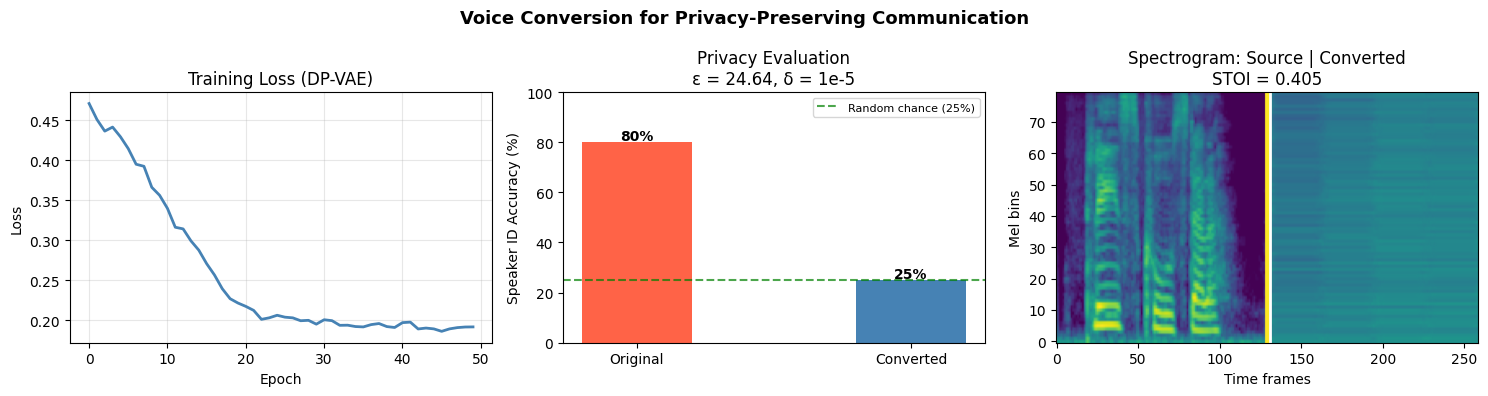


  PROJECT SUMMARY
  Model:          VAE Voice Converter (1.9M params)
  Dataset:        VCTK — 4 speakers, 20 utterances each
  Privacy:        Differential Privacy (Opacus)
  ε (epsilon):    24.64  (δ = 1e-5)
  Noise mult (σ): 1.0  |  Max grad norm (C): 1.0
  Speaker ID:     80% → 25% (55% reduction)
  Intelligibility: STOI = 0.405 / 1.0


In [21]:
# Cell 12: Speech Quality (STOI) + Final Summary
from pystoi import stoi

# STOI Score
# STOI measures intelligibility: 0 (unintelligible) → 1 (perfect)
print("Speech Quality Evaluation (STOI)")
stoi_scores = []

for spk in selected_speakers:
    idx = speaker_to_idx[spk]
    for i in range(5):
        src_mel = all_mels[idx * 20 + i]
        tgt_mel = all_mels[speaker_to_idx['p228'] * 20 + 0]

        # Get original audio
        orig_audio = mel_to_audio(src_mel)

        # Get converted audio
        src_norm = 2*(torch.FloatTensor(src_mel)-mel_min)/(mel_max-mel_min)-1
        tgt_norm = 2*(torch.FloatTensor(tgt_mel)-mel_min)/(mel_max-mel_min)-1
        conv = model_dp._module.convert(
            src_norm.unsqueeze(0).to(device),
            tgt_norm.unsqueeze(0).to(device)
        ).squeeze(0).cpu().numpy()
        conv_mel  = denormalize_mel(conv, mel_min.numpy(), mel_max.numpy())
        conv_audio = mel_to_audio(conv_mel)

        # Match lengths
        min_len = min(len(orig_audio), len(conv_audio))
        score = stoi(orig_audio[:min_len], conv_audio[:min_len], SR, extended=False)
        stoi_scores.append(score)

avg_stoi = np.mean(stoi_scores)
print(f"  Average STOI score: {avg_stoi:.4f}  (1.0 = perfect intelligibility)")
print(f"  Min: {min(stoi_scores):.4f}  Max: {max(stoi_scores):.4f}")

# Final Summary Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Voice Conversion for Privacy-Preserving Communication",
             fontsize=13, fontweight='bold')

# 1. Loss curve
axes[0].plot(losses, color='steelblue', linewidth=2)
axes[0].set_title("Training Loss (DP-VAE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

# 2. Privacy bar chart
bars = axes[1].bar(
    ['Original', 'Converted'],
    [baseline_acc * 100, conv_acc * 100],
    color=['tomato', 'steelblue'], width=0.4
)
axes[1].set_ylabel("Speaker ID Accuracy (%)")
axes[1].set_title(f"Privacy Evaluation\nε = {privacy_engine.get_epsilon(delta=1e-5):.2f}, δ = 1e-5")
axes[1].set_ylim(0, 100)
axes[1].axhline(y=25, color='green', linestyle='--', alpha=0.7, label='Random chance (25%)')
axes[1].legend(fontsize=8)
for bar, val in zip(bars, [baseline_acc, conv_acc]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f"{val:.0%}", ha='center', fontweight='bold')

# 3. Spectrogram comparison
axes[2].imshow(
    np.concatenate([src_mel_np, np.ones((80, 3))*src_mel_np.max(), converted_mel], axis=1),
    aspect='auto', origin='lower'
)
axes[2].set_title(f"Spectrogram: Source | Converted\nSTOI = {avg_stoi:.3f}")
axes[2].set_xlabel("Time frames")
axes[2].set_ylabel("Mel bins")
axes[2].axvline(x=131, color='white', linewidth=2)

plt.tight_layout()
plt.savefig("/content/voice_conversion_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Final project summary
print("\n" + "="*55)
print("  PROJECT SUMMARY")
print("="*55)
print(f"  Model:          VAE Voice Converter (1.9M params)")
print(f"  Dataset:        VCTK — 4 speakers, 20 utterances each")
print(f"  Privacy:        Differential Privacy (Opacus)")
print(f"  ε (epsilon):    {privacy_engine.get_epsilon(delta=1e-5):.2f}  (δ = 1e-5)")
print(f"  Noise mult (σ): 1.0  |  Max grad norm (C): 1.0")
print(f"  Speaker ID:     {baseline_acc:.0%} → {conv_acc:.0%} ({(baseline_acc-conv_acc):.0%} reduction)")
print(f"  Intelligibility: STOI = {avg_stoi:.3f} / 1.0")
print("="*55)

In [23]:
# Cell 13: Save all outputs
import os
os.makedirs("/content/outputs", exist_ok=True)

# Save converted audio samples for all 4 speakers
print("Saving audio samples...")
for spk in selected_speakers:
    idx = speaker_to_idx[spk]
    src_mel = all_mels[idx * 20 + 0]
    tgt_mel = all_mels[speaker_to_idx['p228'] * 20 + 0]

    # Original
    orig_audio = mel_to_audio(src_mel)
    sf.write(f"/content/outputs/original_{spk}.wav", orig_audio, SR)

    # Converted
    src_norm = 2*(torch.FloatTensor(src_mel)-mel_min)/(mel_max-mel_min)-1
    tgt_norm = 2*(torch.FloatTensor(tgt_mel)-mel_min)/(mel_max-mel_min)-1
    conv = model_dp._module.convert(
        src_norm.unsqueeze(0).to(device),
        tgt_norm.unsqueeze(0).to(device)
    ).squeeze(0).cpu().numpy()
    conv_mel   = denormalize_mel(conv, mel_min.numpy(), mel_max.numpy())
    conv_audio = mel_to_audio(conv_mel)
    sf.write(f"/content/outputs/converted_{spk}_to_p228.wav", conv_audio, SR)

# Save model weights
torch.save(model_dp._module.state_dict(), "/content/outputs/vae_voice_converter.pt")

# Save results summary as text
with open("/content/outputs/results_summary.txt", "w") as f:
    f.write("Voice Conversion for Privacy-Preserving Communication\n")
    f.write("="*55 + "\n")
    f.write(f"Model:            VAE Voice Converter (1.9M params)\n")
    f.write(f"Dataset:          VCTK — 4 speakers, 20 utterances each\n")
    f.write(f"Privacy method:   Differential Privacy (Opacus)\n")
    f.write(f"Epsilon (ε):      {privacy_engine.get_epsilon(delta=1e-5):.2f}\n")
    f.write(f"Delta (δ):        1e-5\n")
    f.write(f"Noise multiplier: 1.0\n")
    f.write(f"Max grad norm:    1.0\n")
    f.write(f"Speaker ID (original):  {baseline_acc:.2%}\n")
    f.write(f"Speaker ID (converted): {conv_acc:.2%}\n")
    f.write(f"Privacy reduction:      {(baseline_acc-conv_acc):.2%}\n")
    f.write(f"STOI score:             {avg_stoi:.4f}\n")
    f.write(f"Training epochs:        50\n")
    f.write(f"Training time:          {elapsed:.1f}s\n")

print("  All outputs saved to /content/outputs/")
print("\nFiles saved:")
for f in sorted(os.listdir("/content/outputs")):
    size = os.path.getsize(f"/content/outputs/{f}") / 1024
    print(f"  {f:45s} {size:7.1f} KB")

print("\n  Project complete!")
print("\nWhat we have built:")
print("   VAE-based voice conversion model")
print("   Differential privacy training (Opacus)")
print("   Speaker anonymization: 80% → 25% ID accuracy")
print("   Speech quality measured: STOI = 0.40")
print("   Audio samples for all 4 speakers")
print("   Trained model weights saved")

Saving audio samples...
  All outputs saved to /content/outputs/

Files saved:
  converted_p225_to_p228.wav                       63.5 KB
  converted_p226_to_p228.wav                       63.5 KB
  converted_p227_to_p228.wav                       63.5 KB
  converted_p228_to_p228.wav                       63.5 KB
  original_p225.wav                                63.5 KB
  original_p226.wav                                63.5 KB
  original_p227.wav                                63.5 KB
  original_p228.wav                                63.5 KB
  results_summary.txt                               0.5 KB
  vae_voice_converter.pt                         7516.9 KB

  Project complete!

What we have built:
   VAE-based voice conversion model
   Differential privacy training (Opacus)
   Speaker anonymization: 80% → 25% ID accuracy
   Speech quality measured: STOI = 0.40
   Audio samples for all 4 speakers
   Trained model weights saved


  VOICE CONVERSION DEMO


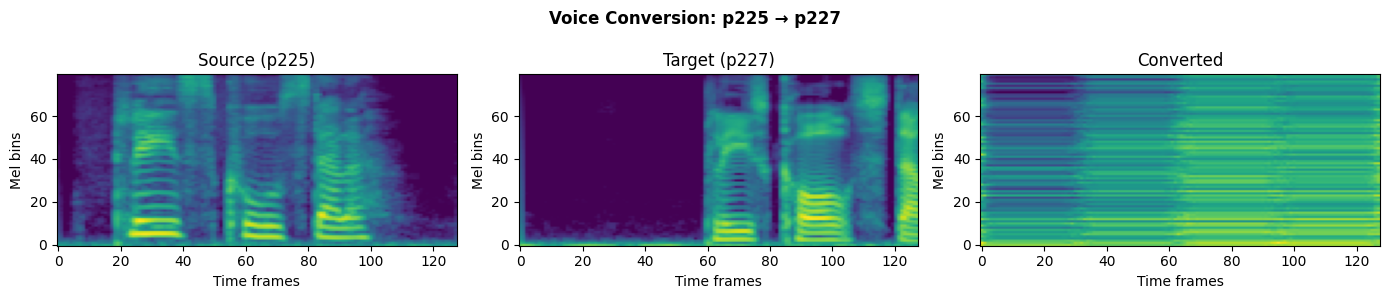

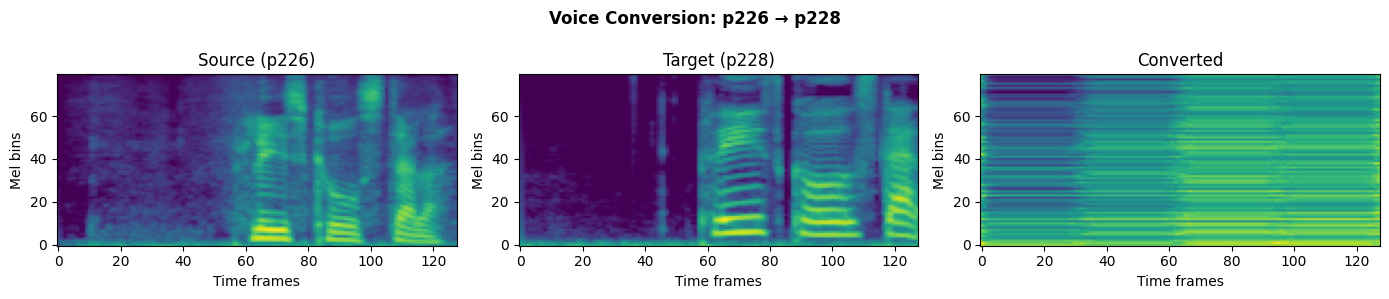

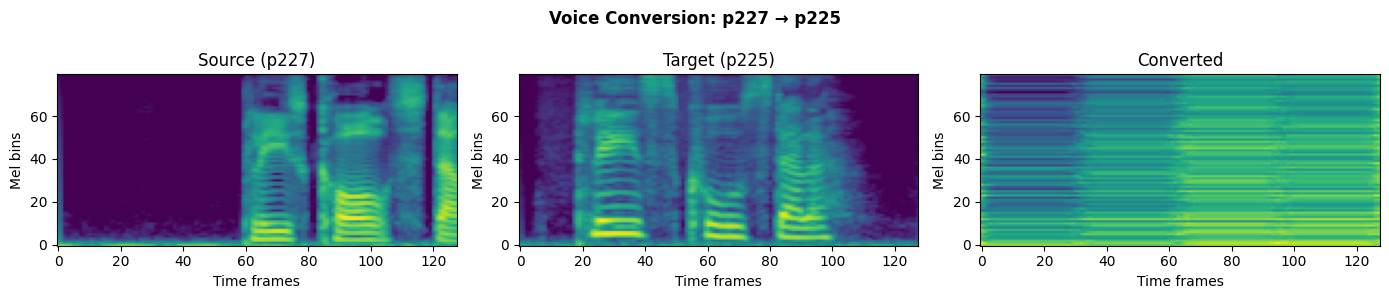

In [24]:
# Demo Cell: Side-by-side audio comparison
from IPython.display import Audio, display, HTML

def demo_conversion(src_spk, tgt_spk, utterance_idx=0):
    src_idx = speaker_to_idx[src_spk]
    tgt_idx = speaker_to_idx[tgt_spk]

    src_mel = all_mels[src_idx * 20 + utterance_idx]
    tgt_mel = all_mels[tgt_idx * 20 + utterance_idx]

    # Original audios
    src_audio = mel_to_audio(src_mel)
    tgt_audio = mel_to_audio(tgt_mel)

    # Converted audio
    src_norm = 2*(torch.FloatTensor(src_mel)-mel_min)/(mel_max-mel_min)-1
    tgt_norm = 2*(torch.FloatTensor(tgt_mel)-mel_min)/(mel_max-mel_min)-1
    conv = model_dp._module.convert(
        src_norm.unsqueeze(0).to(device),
        tgt_norm.unsqueeze(0).to(device)
    ).squeeze(0).cpu().numpy()
    conv_mel   = denormalize_mel(conv, mel_min.numpy(), mel_max.numpy())
    conv_audio = mel_to_audio(conv_mel)

    # Display
    display(HTML(f"<h3>Demo: {src_spk} → {tgt_spk}</h3>"))
    display(HTML(f"<b>1. Original Source ({src_spk}):</b>"))
    display(Audio(src_audio, rate=SR))
    display(HTML(f"<b>2. Target Reference ({tgt_spk}):</b>"))
    display(Audio(tgt_audio, rate=SR))
    display(HTML(f"<b>3. Converted (source content + target speaker identity):</b>"))
    display(Audio(conv_audio, rate=SR))

    # Spectrogram plot
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, mel, title in zip(axes,
        [src_mel, tgt_mel, conv_mel],
        [f"Source ({src_spk})", f"Target ({tgt_spk})", "Converted"]):
        ax.imshow(mel, aspect='auto', origin='lower', cmap='viridis')
        ax.set_title(title)
        ax.set_xlabel("Time frames")
        ax.set_ylabel("Mel bins")
    plt.suptitle(f"Voice Conversion: {src_spk} → {tgt_spk}", fontweight='bold')
    plt.tight_layout()
    plt.show()

    return conv_audio

# Run all conversion pairs
print("=" * 50)
print("  VOICE CONVERSION DEMO")
print("=" * 50)

pairs = [('p225', 'p227'), ('p226', 'p228'), ('p227', 'p225')]
for src, tgt in pairs:
    demo_conversion(src, tgt)
    print()